# Modeling

**Project:** Airbnb Pricing Analysis

**Team:** Jessie Dicker, Norma Arredondo

**Date:** April 19, 2026




## Table of Contents
1. Load Data
2. All Models - Default Parameters
3. Cross-Validation
4. Hyperparameter Tuning - GridSearch CV
5. Final Model Comparison
6. Save Best Model
7. Key Findings Summary

In [1]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## settings
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

## 1. Load Data
Load the CSV files from Notebook 3.

In [7]:
# load data from preprocessing notebook
X_train_base = pd.read_csv('../data/processed/X_train.csv')
X_test_base = pd.read_csv('../data/processed/X_test.csv')
y_train_base = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test_base = pd.read_csv('../data/processed/y_test.csv').squeeze()

# load data from feature engineering notebook
X_train = pd.read_csv('../data/modeling/X_train.csv')
X_test = pd.read_csv('../data/modeling/X_test.csv')
y_train = pd.read_csv('../data/modeling/y_train.csv').squeeze()
y_test = pd.read_csv('../data/modeling/y_test.csv').squeeze()

## save WITH SCALE
X_train_standard = pd.read_csv('../data/modeling/X_train_final.csv')
X_test_standard = pd.read_csv('../data/modeling/x_test_final.csv')

print('Shapes\n')
print(f'Training (baseline): {X_train_base.shape}')
print(f'Training (with engineered features): {X_train.shape}')
print(f'Training (Standard): {X_train_standard.shape}')
print(f'Test (baseline):                 {X_test_base.shape}')
print(f'Test (with engineered features): {X_test.shape}')
print(f'Test (Scaled):                   {X_test_standard.shape}')

Shapes

Training (baseline): (39107, 10)
Training (with engineered features): (39107, 235)
Training (Standard): (39107, 235)
Test (baseline):                 (9777, 10)
Test (with engineered features): (9777, 235)
Test (Scaled):                   (9777, 235)


In [8]:
# Confirm Column Alignment
assert list(X_train.columns) == list(X_test.columns), \
    "Column mismatch between X_train and X_test"
assert list(X_train_standard.columns) == list(X_test_standard.columns), \
    "Column mismatch between X_train_standard and X_test_standard"

print("Column alignment confirmed for unscaled sets")
print("Column alignment confirmed for scaled sets")

Column alignment confirmed for unscaled sets
Column alignment confirmed for scaled sets


In [9]:
# Check Target Distribution and range
print('y_train distribution:')
print(y_train.describe().round(2))

print('\ny_test distribution:')
print(y_test.describe().round(2))

print('\nTarget Range:')
print(f"\ny_train range: ${int(y_train.min())} — ${int(y_train.max())}")
print(f"y_test range: ${int(y_test.min())} — ${int(y_test.max())}")

y_train distribution:
count    39107.00
mean       151.63
std        225.58
min         10.00
25%         69.00
50%        105.00
75%        175.00
max      10000.00
Name: price, dtype: float64

y_test distribution:
count     9777.00
mean       157.24
std        291.29
min         10.00
25%         69.00
50%        109.00
75%        179.00
max      10000.00
Name: price, dtype: float64

Target Range:

y_train range: $10 — $10000
y_test range: $10 — $10000


In [10]:
# Outliers were found in price
## Cap target variable at 99th percentile of training data
price_cap = y_train.quantile(0.99)
print(f'99th percentile price cap: ${price_cap:.0f}')

y_train_capped = y_train.clip(upper=price_cap)

print(f'Original y_train max: ${y_train.max():.2f}')
print(f'Capped y_train max:   ${y_train_capped.max():.2f}')

print(f"Rows affected in train: {(y_train > price_cap).sum()}")

99th percentile price cap: $794
Original y_train max: $10000.00
Capped y_train max:   $793.76
Rows affected in train: 392


There are outliers in our target variable, `price`, so we decided to cap the target variable at the 99th percentile to avoid any negative R² scores. The cap is fit on y_train 
 

In [11]:
# print new Target distribution and range
print('New y_train distribution:')
print(y_train_capped.describe().round(2))

print('\nNewTarget Range:')
print(f"\ny_train range: ${int(y_train_capped.min())} — ${int(y_train_capped.max())}")


New y_train distribution:
count    39107.00
mean       143.39
std        120.87
min         10.00
25%         69.00
50%        105.00
75%        175.00
max        793.76
Name: price, dtype: float64

NewTarget Range:

y_train range: $10 — $793


### Observations 


- **Shapes:**

  X_train: (39107, 235) and X_test: (9777, 235)

  
- **Original Target Range (before capping):**


  y_train range is between 10 and 10,000


- **New Target Range (after capping):**

  y_train range is between 10 and 793


  
- **Scaled vs. Unscaled for each model type:**


  Linear Regression -> Scaled and Unscaled Data 

  Ridge Regression -> Scaled Data

  Lasso Regression -> Scaled Data

  Decision Tree -> Unscaled Data

  Random Forest -> Unscaled Data


The shapes of X_train and X_test are the same as those in Notebook 3. Capping the `price` was necessary to avoid a negative R² that affects the models. After capping, the Target Range changed. Throughout the Notebook, we will use the capped data set. 


## 2. All Models - Default Parameters

Use different fitting models to train, predict, and print metrics. 

In [12]:
# store results
results = []

### Model 1: Linear Regression 
Both unscaled and scaled data are used

#### Data in Feature Engineering (Unscaled)

In [13]:
# import linear regression
from sklearn.linear_model import LinearRegression

lr_fe = LinearRegression()
lr_fe.fit(X_train, y_train_capped)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
# linear regression (unscaled) train metrics
y_train_pred_lrfe = lr_fe.predict(X_train)

In [15]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2_train_lrfe = r2_score(y_train_capped, y_train_pred_lrfe)
rmse_train_lrfe = np.sqrt(mean_squared_error(y_train_capped, y_train_pred_lrfe))

print(f'No Scaling Linear Regression on train test: R² = {r2_train_lrfe:.4f}, RMSE = {rmse_train_lrfe:.4f}')


No Scaling Linear Regression on train test: R² = 0.3682, RMSE = 96.0727


In [18]:
# linear regression (unscaled) test metrics
y_pred_lrfe = lr_fe.predict(X_test)

In [17]:
r2_lrfe = r2_score(y_test, y_pred_lrfe)
rmse_lrfe = np.sqrt(mean_squared_error(y_test, y_pred_lrfe))

# store test metrics
results.append({'Model': 'No Scaling Linear Regression', 'R²': r2_lrfe, 'RMSE': rmse_lrfe})

print(f'No Scaling Linear Regression on test set: R² = {r2_lrfe:.4f}, RMSE = {rmse_lrfe:.4f}')

No Scaling Linear Regression on test set: R² = 0.0836, RMSE = 278.8431


#### Data in Feature Engineering with Scale

In [19]:
# use scale data
lr = LinearRegression()
lr.fit(X_train_standard, y_train_capped)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
# linear regression with scale train metrics
y_train_pred_lr = lr.predict(X_train_standard)

In [21]:
# train R² and RMSE
r2_train_lr = r2_score(y_train_capped, y_train_pred_lr)
rmse_train_lr = np.sqrt(mean_squared_error(y_train_capped, y_train_pred_lr))

print(f'Linear Regression with Scale on train set: R² = {r2_train_lr:.4f}, RMSE = {rmse_train_lr:.4f}')

Linear Regression with Scale on train set: R² = 0.3682, RMSE = 96.0727


In [22]:
# linear regression with scale test metrics
y_pred_lr = lr.predict(X_test_standard)

In [23]:
# test R² and RMSE
r2_lr  = r2_score(y_test, y_pred_lr )
rmse_lr  = np.sqrt(mean_squared_error(y_test, y_pred_lr ))

results.append({'Model': 'Scaling Linear Regression','R²': r2_lr, 'RMSE': rmse_lr})

print(f'Linear Regression with Scale on test set: R² = {r2_lr :.4f}, RMSE = {rmse_lr :.4f}')

Linear Regression with Scale on test set: R² = 0.0836, RMSE = 278.8431


#### Linear Regression Observation

| Model | Train R² | Test  R² |  Train RMSE | Test RSME |
| -------- | -------- | -------- | -------- | -------- |
| No Scaling Linear Regression | 0.3682 | 0.0836 | 96.0727 | 278.8431 |
| Linear Regression with Scale | 0.3682 | 0.0836 | 96.0727 | 278.8431 |


There is a 0.28 difference in the R² gap for the unscaled linear regression.

There is a 0.28 difference in the R² gap for the scaled linear regression.

Both scaled and unscaled Linear Regression are likely underfitting.

### Model 2: Ridge Regression
Scaled data only. L2 regularisation

#### Data in Feature Engineering with Scale

In [24]:
# import ridge regression
from sklearn.linear_model import  Ridge

# set default alpha=1.0
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_standard, y_train_capped) # use scaled

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [25]:
# ridge regression - train metrics
y_train_pred_rg = ridge.predict(X_train_standard)
r2_train_rg = r2_score(y_train_capped, y_train_pred_rg)
rmse_train_rg = np.sqrt(mean_squared_error(y_train_capped, y_train_pred_rg))

print(f'Scaling Ridge Regression on train set: R² = {r2_train_rg:.4f}, RMSE = {rmse_train_rg:.4f}')

Scaling Ridge Regression on train set: R² = 0.3679, RMSE = 96.0984


In [26]:
# ridge regression - test metrics
y_pred_rg = ridge.predict(X_test_standard)
r2_rg = r2_score(y_test, y_pred_rg)
rmse_rg = np.sqrt(mean_squared_error(y_test, y_pred_rg))

results.append({'Model': 'Scaling Ridge Regression', 'R²': r2_rg, 'RMSE': rmse_rg})

print(f'Scaling Ridge Regression on test set: R² = {r2_rg:.4f}, RMSE = {rmse_rg:.4f}')

Scaling Ridge Regression on test set: R² = 0.0837, RMSE = 278.8261


#### Ridge Regression Observations

| Model | Train R² | Test  R² |  Train RMSE | Test RSME |
| -------- | -------- | -------- | -------- | -------- |
| Scaling Ridge Regression | 0.3679 | 0.0837 | 96.0984 | 278.8261 |


There is a 0.28 difference in the R² gap for the scaled ridge regression.

The scaled Ridge Regression is likely underfitting.

### Model 3: Lasso Regression
Scaled data only. L1 regularisation

#### Data in Feature Engineering with Scale

In [27]:
# import lasso regression
from sklearn.linear_model import  Lasso

# set default alpha = 0.01
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_standard, y_train_capped)

,alpha,0.01
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [28]:
# lasso regression - train metrics
y_train_pred_ls = lasso.predict(X_train_standard)
r2_train_ls = r2_score(y_train_capped, y_train_pred_ls)
rmse_train_ls = np.sqrt(mean_squared_error(y_train_capped, y_train_pred_ls))

print(f'Scaling Lasso Regression on train set: R² = {r2_train_ls:.4f}, RMSE = {rmse_train_ls:.4f}')

Scaling Lasso Regression on train set: R² = 0.3659, RMSE = 96.2489


In [29]:
# lasso regression - test metrics
y_pred_ls = lasso.predict(X_test_standard)
r2_ls = r2_score(y_test, y_pred_ls)
rmse_ls = np.sqrt(mean_squared_error(y_test, y_pred_ls))

results.append({'Model': 'Scaling Lasso Regression', 'R²': r2_ls, 'RMSE': rmse_ls})

print(f'Scaling Lasso Regression on test set: R² = {r2_ls:.4f}, RMSE = {rmse_ls:.4f}')


Scaling Lasso Regression on test set: R² = 0.0836, RMSE = 278.8445


In [30]:
# Check features Lasso zeroed out
zeroed = (lasso.coef_ == 0).sum()
total = len(lasso.coef_)
print(f'\nLasso zeroed out {zeroed} of {total} features ({zeroed/total*100:.1f}%)')

print('\nFeature coefficients:')
for feature, coef in zip(X_train_standard.columns, lasso.coef_):
    print(f'  {feature}: {coef:.4f}')


Lasso zeroed out 109 of 235 features (46.4%)

Feature coefficients:
  latitude: -8.1585
  longitude: -2.3551
  minimum_nights: -34.4928
  number_of_reviews: -7.5253
  reviews_per_month: -1.0945
  calculated_host_listings_count: 1.0783
  availability_365: 21.8675
  log_minimum_nights: 20.0050
  dist_to_times_square: -12.5471
  is_new_listing: 28.6011
  review_density: -0.3198
  location_tier_encoded: -9.9949
  room_type_encoded: 85.6226
  neighbourhood_group_Brooklyn: -11.0188
  neighbourhood_group_Manhattan: 18.4393
  neighbourhood_group_Queens: -1.3734
  neighbourhood_group_Staten Island: -26.8993
  neighbourhood_Arden Heights: -0.0000
  neighbourhood_Arrochar: 0.0000
  neighbourhood_Arverne: 18.8660
  neighbourhood_Astoria: -21.1275
  neighbourhood_Bath Beach: -0.0000
  neighbourhood_Battery Park City: 20.7934
  neighbourhood_Bay Ridge: 0.0000
  neighbourhood_Bay Terrace: 0.0000
  neighbourhood_Bay Terrace, Staten Island: 0.0000
  neighbourhood_Baychester: 0.0000
  neighbourhood_Bay

In [31]:
# Drop the features that Lasso identified with coefficient = 0 in order to simplify model

selected_features = X_train.columns[lasso.coef_ != 0]

# make a copy of the full datasets
X_train_full = X_train.copy()
X_test_full = X_test.copy()

X_train = X_train[selected_features]
X_test = X_test[selected_features]

#### Lasso Regression Observations

| Model | Train R² | Test  R² |  Train RMSE | Test RSME |
| -------- | -------- | -------- | -------- | -------- |
| Scaling Lasso Regression | 0.3659 | 0.0836 | 96.2489 | 278.8445 |


There is a 0.28 difference in the R² gap for the scaled lasso regression.

There likely underfitting in a scaled Lasso Regression.

Lasso zeroed out 109 of 235 features (46.4%) with alpha=0.01. The largest coefficients are `log_minimum_nights` (35.3841), `location_tier_encoded` (-35.2976), and `minimum_nights` (-40.1402). They are strong predictors. 

### Model 4: Decision Tree
Unscaled data only

#### Data in Feature Engineering  (Unscaled)

In [33]:
# import decision tree
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=10, random_state=4950)
dt.fit(X_train, y_train_capped)

,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,4950
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [34]:
# decision tree - train metrics
y_train_pred_dt = dt.predict(X_train)
r2_train_dt = r2_score(y_train_capped, y_train_pred_dt)
rmse_train_dt = np.sqrt(mean_squared_error(y_train_capped, y_train_pred_dt))

print(f'No Scaling Decision Tree on train set: R² = {r2_train_dt:.4f}, RMSE = {rmse_train_dt:.4f}')

No Scaling Decision Tree on train set: R² = 0.5255, RMSE = 83.2622


In [35]:
# decision tree - test Metrics
y_pred_dt = dt.predict(X_test)
r2_dt = r2_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

results.append({'Model': 'No Scaling Decision Tree', 'R²': r2_dt, 'RMSE': rmse_dt})

print(f'No Scaling Decision Tree: R² = {r2_dt:.4f}, RMSE = {rmse_dt:.4f}')

No Scaling Decision Tree: R² = 0.0844, RMSE = 278.7203


#### Decision Tree Observations

| Model | Train R² | Test  R² |  Train RMSE | Test RSME |
| -------- | -------- | -------- | -------- | -------- |
| No Scaling Decision Tree | 0.5255 | 0.0844 | 83.2622 | 278.7203 |


There is a 0.44 difference in the R² gap for the unscaled decision tree.

There is overfitting in the unscaled Decision Tree because of the 0.44 gap.

### Model 5: Random Forest
Unscaled data only

#### Data in Feature Engineering (Unscaled)

In [36]:
# import random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=4950, n_jobs=-1)
rf.fit(X_train, y_train_capped)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
# random forest - train metrics
y_train_pred_rf = rf.predict(X_train)
r2_train_rf = r2_score(y_train_capped, y_train_pred_rf)
rmse_train_rf = np.sqrt(mean_squared_error(y_train_capped, y_train_pred_rf))

print(f'No Scaling Random Forest: R² = {r2_train_rf:.4f}, RMSE = {rmse_train_rf:.4f}')

No Scaling Random Forest: R² = 0.9203, RMSE = 34.1330


In [38]:
# random forest - test metrics
y_pred_rf = rf.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

results.append({'Model': 'No Scaling Random Forest', 'R²': r2_rf, 'RMSE': rmse_rf})

print(f'No Scaling Random Forest: R² = {r2_rf:.4f}, RMSE = {rmse_rf:.4f}')

No Scaling Random Forest: R² = 0.1081, RMSE = 275.0825


#### Random Forest Observation

| Model | Train R² | Test  R² |  Train RMSE | Test RSME |
| -------- | -------- | -------- | -------- | -------- |
| No Scaling Random Forest | 0.9203 | 0.1081 | 34.1330 | 275.0825 |


There is a 0.8122 difference in the R² gap for the unscaled random forest.


There is a severe overfitting in the unscaled Random Forest because of the wide gap (0.8122).

### Model 6: Gradient Boosting
Unscaled data only

#### Data in Feature Engineering (Unscaled)

In [39]:
# import gradient boosting 
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=100, max_depth=4,
                               learning_rate=0.1, random_state=4950)
gb.fit(X_train, y_train_capped)


,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,4
,min_impurity_decrease,0.0
,init,None


In [40]:
# gradient boosting - train metrics
y_train_pred_gb = gb.predict(X_train)
r2_train_gb = r2_score(y_train_capped, y_train_pred_gb)
rmse_train_gb = np.sqrt(mean_squared_error(y_train_capped, y_train_pred_gb))

print(f'No Scaling Gradient Boosting on train set: R² = {r2_train_gb:.4f}, RMSE = {rmse_train_gb:.4f}')


No Scaling Gradient Boosting on train set: R² = 0.4664, RMSE = 88.2932


In [41]:
# gradient boosting - test metric
y_pred_gb = gb.predict(X_test)
r2_gb = r2_score(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

results.append({'Model': 'No Scaling Gradient Boosting', 'R²': r2_gb, 'RMSE': rmse_gb})

print(f'No Scaling Gradient Boosting on test set: R² = {r2_gb:.4f}, RMSE = {rmse_gb:.4f}')


No Scaling Gradient Boosting on test set: R² = 0.1011, RMSE = 276.1680


#### Gradient Boosting Observation

| Model | Train R² | Test  R² |  Train RMSE | Test RSME |
| -------- | -------- | -------- | -------- | -------- |
| No Scaling Gradient Boosting | 0.4664 | 0.1011 | 88.2932 | 276.1680 |


There is a 0.37 difference in the R² gap for the unscaled gradient boosting.

There is overfitting in the unscaled Gradient Boosting because of the noticeable gap of 0.37, but it is more balanced.

#### Comparison

In [42]:
# create comparison table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R²',ascending=False)

results_df

,Model,R²,RMSE
5,No Scaling Random Forest,0.108112,275.082480
6,No Scaling Gradient Boosting,0.101059,276.168034
4,No Scaling Decision Tree,0.084366,278.720324
2,Scaling Ridge Regression,0.083671,278.826129
0,No Scaling Linear Regression,0.083560,278.843063
1,Scaling Linear Regression,0.083560,278.843063
3,Scaling Lasso Regression,0.083550,278.844523


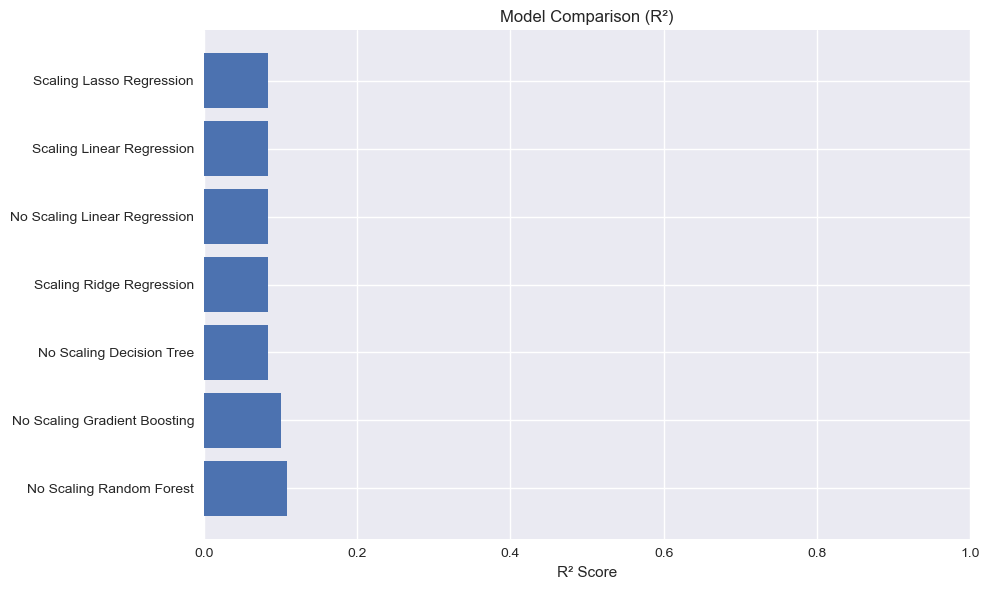

In [43]:
# barplot of model comparison by Test R²
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(results_df['Model'], results_df['R²'])

ax.set_xlabel('R² Score')
ax.set_title('Model Comparison (R²)')
ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()



### Observations

**Best Performer:**
    The best performing model was the No Scaling Random Forest model because it had the highest R² (0.1081) and lowest RMSE. It is able to capture the nonlinear relationship of the data better than the linear models. 
    

**Models with overfitting:** 
- Random Forest: severe overfitting (Train R² = 0.9203, Test R² = 0.1081)
- Decision Tree: moderate overfitting (Train R²= 0.5255, Test R² = 0.0844)
- Gradient Boosting: slight overfitting, still well-balanced. 

**Models to tune:**
- Random Forest
- Gradient Boosting


## 3. Cross-Validation
Run 5-fold cross-validation on all models

In [44]:
# Cross-validation

from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=5, shuffle=True, random_state=4950)
cv_results = []


In [45]:
# Linear Regression (Unscaled)
lr_cv = LinearRegression()

scores_lr = cross_val_score(lr_cv, X_train, y_train_capped, cv=cv,scoring='r2',n_jobs=-1)

cv_results.append({'Model': 'Linear Regression (Unscaled)','CV Mean R²': round(scores_lr.mean(), 4),'CV Std': round(scores_lr.std(), 4),
    'Fold 1': round(scores_lr[0], 4),'Fold 2': round(scores_lr[1], 4),'Fold 3': round(scores_lr[2], 4),'Fold 4': round(scores_lr[3], 4),
    'Fold 5': round(scores_lr[4], 4)})


print(f"Linear Regression (Unscaled)     mean={scores_lr.mean():.4f} std={scores_lr.std():.4f}  folds={np.round(scores_lr,3)}")


Linear Regression (Unscaled)     mean=0.3614 std=0.0110  folds=[0.356 0.351 0.379 0.352 0.37 ]


In [46]:
# Linear Regression (Scaled)
scores_lrs = cross_val_score(lr_cv, X_train_standard, y_train_capped, cv=cv,scoring='r2',n_jobs=-1)

cv_results.append({'Model': 'Linear Regression (Scaled)','CV Mean R²': round(scores_lrs.mean(), 4),'CV Std': round(scores_lrs.std(), 4),
    'Fold 1': round(scores_lrs[0], 4),'Fold 2': round(scores_lrs[1], 4),'Fold 3': round(scores_lrs[2], 4),'Fold 4': round(scores_lrs[3], 4),
    'Fold 5': round(scores_lrs[4], 4)})


print(f"Linear Regression (Scaled)     mean={scores_lrs.mean():.4f} std={scores_lrs.std():.4f}  folds={np.round(scores_lrs,3)}")


Linear Regression (Scaled)     mean=0.3604 std=0.0110  folds=[0.355 0.349 0.378 0.351 0.369]


In [47]:
# Ridge Regression
ridge_cv = Ridge()

scores_rg = cross_val_score(ridge_cv, X_train_standard, y_train_capped, cv=cv,scoring='r2', n_jobs=-1)


cv_results.append({'Model': 'Ridge Regression','CV Mean R²': round(scores_rg.mean(), 4),'CV Std': round(scores_rg.std(), 4),
    'Fold 1': round(scores_rg[0], 4),'Fold 2': round(scores_rg[1], 4),'Fold 3': round(scores_rg[2], 4),'Fold 4': round(scores_rg[3], 4),
    'Fold 5': round(scores_rg[4], 4)})

print(f"Ridge Regression (Scaled)     mean={scores_rg.mean():.4f}  "
      f"std={scores_rg.std():.4f}  folds={np.round(scores_rg,3)}")

Ridge Regression (Scaled)     mean=0.3609  std=0.0113  folds=[0.356 0.349 0.378 0.352 0.37 ]


In [48]:
# Lasso Regression
lasso_cv = Lasso(alpha=0.01)

scores_ls = cross_val_score(lasso_cv, X_train_standard, y_train_capped, cv=cv,scoring='r2', n_jobs=-1)

cv_results.append({'Model': 'Lasso Regression','CV Mean R²': round(scores_ls.mean(), 4),'CV Std': round(scores_ls.std(), 4),
    'Fold 1': round(scores_ls[0], 4),'Fold 2': round(scores_ls[1], 4),'Fold 3': round(scores_ls[2], 4),'Fold 4': round(scores_ls[3], 4),
    'Fold 5': round(scores_ls[4], 4)})

print(f"Lasso Regression (Scaled)     mean={scores_ls.mean():.4f}  std={scores_ls.std():.4f}  folds={np.round(scores_ls,3)}")

Lasso Regression (Scaled)     mean=0.3608  std=0.0115  folds=[0.356 0.349 0.378 0.351 0.37 ]


In [49]:
# Decision Tree

dt_cv = DecisionTreeRegressor(max_depth=10, random_state=4950) 

scores_dt = cross_val_score(dt_cv, X_train, y_train_capped, cv=cv,scoring='r2', n_jobs=-1)


cv_results.append({'Model': 'Decision Tree','CV Mean R²': round(scores_dt.mean(), 4),'CV Std': round(scores_dt.std(), 4),
    'Fold 1': round(scores_dt[0], 4),'Fold 2': round(scores_dt[1], 4),'Fold 3': round(scores_dt[2], 4),'Fold 4': round(scores_dt[3], 4),
    'Fold 5': round(scores_dt[4], 4)})

print(f"Decision Tree (Unscaled)     mean={scores_dt.mean():.4f}  std={scores_dt.std():.4f}  folds={np.round(scores_dt,3)}")

Decision Tree (Unscaled)     mean=0.3033  std=0.0075  folds=[0.298 0.302 0.317 0.296 0.304]


In [50]:
# Random Forest
rf_cv = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=4950, n_jobs=-1)

scores_rf = cross_val_score(rf_cv, X_train, y_train_capped, cv=cv,scoring='r2', n_jobs=-1)


cv_results.append({'Model': 'Random Forest','CV Mean R²': round(scores_rf.mean(), 4),'CV Std': round(scores_rf.std(), 4),
    'Fold 1': round(scores_rf[0], 4),'Fold 2': round(scores_rf[1], 4),'Fold 3': round(scores_rf[2], 4),'Fold 4': round(scores_rf[3], 4),
    'Fold 5': round(scores_rf[4], 4)})

print(f"Random Forest (Unscaled)     mean={scores_rf.mean():.4f}  std={scores_rf.std():.4f}  folds={np.round(scores_rf,3)}")


Random Forest (Unscaled)     mean=0.4251  std=0.0227  folds=[0.391 0.418 0.462 0.425 0.429]


In [51]:
# Gradient Boosting
gb_cv = GradientBoostingRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=4950)

scores_gb = cross_val_score(gb_cv, X_train, y_train_capped, cv=cv,scoring='r2', n_jobs=-1)

cv_results.append({'Model': 'Gradient Boosting','CV Mean R²': round(scores_gb.mean(), 4),'CV Std': round(scores_gb.std(), 4),
    'Fold 1': round(scores_gb[0], 4),'Fold 2': round(scores_gb[1], 4), 'Fold 3': round(scores_gb[2], 4),'Fold 4': round(scores_gb[3], 4),
    'Fold 5': round(scores_gb[4], 4)})

print(f"Gradient Boosting (Unscaled)     mean={scores_gb.mean():.4f}  std={scores_gb.std():.4f}  folds={np.round(scores_gb,3)}")


Gradient Boosting (Unscaled)     mean=0.4211  std=0.0150  folds=[0.411 0.401 0.444 0.42  0.43 ]


In [52]:
# Summary DataFrame
cv_df = pd.DataFrame(cv_results).sort_values('CV Mean R²', ascending=False).reset_index(drop=True)
print(cv_df.to_string(index=False))

                       Model  CV Mean R²  CV Std  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5
               Random Forest      0.4251  0.0227  0.3913  0.4185  0.4621  0.4252  0.4285
           Gradient Boosting      0.4211  0.0150  0.4108  0.4005  0.4439  0.4201  0.4302
Linear Regression (Unscaled)      0.3614  0.0110  0.3558  0.3508  0.3787  0.3522  0.3697
            Ridge Regression      0.3609  0.0113  0.3556  0.3492  0.3784  0.3516  0.3700
            Lasso Regression      0.3608  0.0115  0.3557  0.3488  0.3784  0.3508  0.3700
  Linear Regression (Scaled)      0.3604  0.0110  0.3552  0.3491  0.3779  0.3515  0.3685
               Decision Tree      0.3033  0.0075  0.2976  0.3023  0.3171  0.2957  0.3036


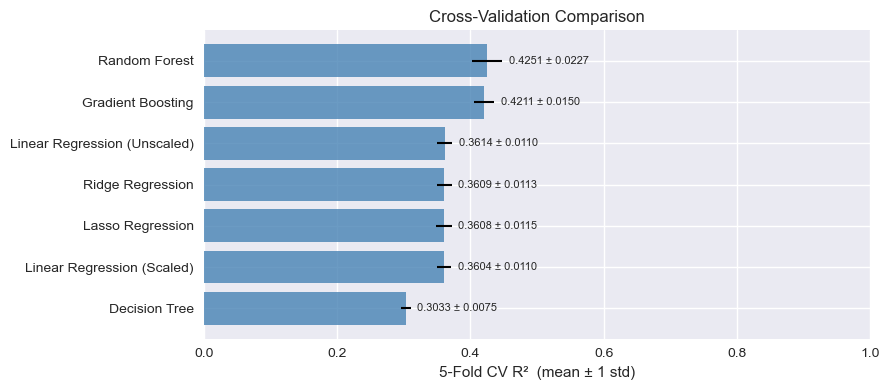

In [53]:
# Visualise CV mean ± 1 std
cv_df = pd.DataFrame(cv_results).sort_values('CV Mean R²', ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(cv_df['Model'], cv_df['CV Mean R²'],
        xerr=cv_df['CV Std'], color='steelblue', alpha=0.8,
        error_kw=dict(ecolor='black', capsize=5, lw=1.5))
ax.set_xlabel('5-Fold CV R²  (mean ± 1 std)')
ax.set_title('Cross-Validation Comparison')
ax.set_xlim(0, 1.0)
for i, row in cv_df.iterrows():
    ax.text(row['CV Mean R²'] + row['CV Std'] + 0.01,
            list(cv_df.index).index(i),
            f"{row['CV Mean R²']:.4f} ± {row['CV Std']:.4f}",
            va='center', fontsize=8)
plt.tight_layout()
plt.show()


### Observations


**CV Mean and Test set results:**

CV means are higher than the test R² scores.

Random Forest has a CV Mean of 0.4251 while Test R² is 0.1081. 

Gradient Boosting has a CV Mean of 0.4211 while Test R² is 0.1011.

Unscaled Linear Regression has a CV Mean of 0.3614 while Test R² is 0.0836.

Decision Tree has a CV Mean 0.3033 while Test R² is 0.0844.

Scaled Linear Regression has a CV Mean of 0.3604 while Test R² is 0.0836.


**Models with CV Std > 0.03:**

All seven models have CV Std below 0.03. There are no potentially unstable models. Decision Tree has the lowest std (0.0075), but its mean low R² suggests underperformance.


| Model | CV Std | 
| -------- | -------- |
| Random Forest | 0.0227 |
| Gradient Boosting | 0.0150 | 
| Lasso Regression | 0.0115 |
| Ridge Regression | 0.0113 |
| Linear Regression (Unscaled) | 0.0110 | 
| Linear Regression (Scaled) | 0.0110 |
| Decision Tree | 0.0075 |        


## 4. Hyperparameter Tuning - GridSearchCV

In [54]:
from sklearn.model_selection import GridSearchCV

### Ridge Regression Model Tuning

In [102]:
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

ridge_grid = GridSearchCV(Ridge(),
                         param_grid = param_grid,
                         cv=cv,
                         scoring='r2', n_jobs= -1)

ridge_grid.fit(X_train_standard, y_train_capped)

,estimator,Ridge()
,param_grid,"{'alpha': [0.001, 0.01, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,1


In [103]:
print(f'Best alpha: {ridge_grid.best_params_['alpha']}')
print(f'CV R² with best alpha: {ridge_grid.best_score_:.6f}')

Best alpha: 1
CV R² with best alpha: 0.360939


In [109]:
best_ridge_cv = cross_val_score(ridge_grid.best_estimator_, X_train_standard, y_train_capped,
                                cv=cv, scoring='r2', n_jobs=-1)
print(f"Best estimator CV mean ± std: {best_ridge_cv.mean():.4f} ± {best_ridge_cv.std():.4f}")

Best estimator CV mean ± std: 0.3609 ± 0.0113


In [104]:
ridge_cv_df = pd.DataFrame(ridge_grid.cv_results_)[
    ['rank_test_score', 'param_alpha', 'mean_test_score', 'std_test_score']
]
ridge_cv_df.columns = ['rank', 'alpha', 'mean_R²', 'std_R²']
print(ridge_cv_df.sort_values('rank').head(5).round(6).to_string(index=False))

 rank  alpha  mean_R²   std_R²
    1  1.000 0.360939 0.011304
    2 10.000 0.360702 0.011959
    3  0.100 0.360550 0.011049
    4  0.010 0.360456 0.011020
    5  0.001 0.360445 0.011018


In [79]:
y_pred = ridge_grid.best_estimator_.predict(X_test_standard)

In [80]:
print('=== Ridge Regression (Tuned) ===')
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

results.append({'Model': 'Ridge Regression (tuned)', 'R²': r2, 'RMSE': rmse})
print(f'Ridge Regression: R² = {r2:.6f}, RMSE = {rmse:.6f}')

=== Ridge Regression (Tuned) ===
Ridge Regression: R² = 0.083671, RMSE = 278.826129


In [81]:
# train vs test comparison
y_train_pred = ridge_grid.best_estimator_.predict(X_train_standard)

r2_train = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

print("\n=== Train vs Test Comparison (Ridge) ===")
print(f"Train R²: {r2_train:.6f}, RMSE: {rmse_train:.6f}")
print(f"Test  R²: {r2:.6f}, RMSE: {rmse:.6f}")


=== Train vs Test Comparison (Ridge) ===
Train R²: 0.129581, RMSE: 210.451951
Test  R²: 0.083671, RMSE: 278.826129


The tuned Ridge Regression model shows a small gap between the training and the test set R², which indicates mild overfitting. Both the test and training R² are low, indicating that even with tuning the Ridge Regression model is still underfitting. 

### Random Forest Tuning (depth and feature sampling)

In [106]:
param_grid={
        'n_estimators': [100, 200],
        'max_depth':    [8, 12, 15, None],
        'max_features': ['sqrt', 0.5],
    }

rf_grid = GridSearchCV(RandomForestRegressor(random_state=4950, n_jobs=-1),
                      param_grid= param_grid,
                      cv=cv, scoring='r2', n_jobs=-1)

rf_grid.fit(X_train, y_train_capped)

print(f"Best params: {rf_grid.best_params_}")
print(f"CV R²:       {rf_grid.best_score_:.4f}")
print()

# Top 5 combinations
rf_cv_df = pd.DataFrame(rf_grid.cv_results_)[
    ['rank_test_score', 'param_n_estimators', 'param_max_depth', 'param_max_features',
     'mean_test_score', 'std_test_score']
]
rf_cv_df.columns = ['rank', 'n_estimators', 'max_depth', 'max_features', 'mean_R²', 'std_R²']
print("Top 5 combinations:")
print(rf_cv_df.sort_values('rank').head(5).round(4).to_string(index=False))

/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'max_depth': 15, 'max_features': 0.5, 'n_estimators': 200}
CV R²:       0.4461

Top 5 combinations:
 rank  n_estimators max_depth max_features  mean_R²  std_R²
    1           200        15          0.5   0.4461  0.0212
    2           100        15          0.5   0.4445  0.0213
    3           200        12          0.5   0.4444  0.0186
    4           100        12          0.5   0.4430  0.0190
    5           200      None          0.5   0.4376  0.0224


In [115]:
best_rf_cv = cross_val_score(
    rf_grid.best_estimator_, X_train, y_train_capped,
    cv=cv, scoring='r2', n_jobs=-1
)
print(f"Best estimator CV mean ± std: {best_rf_cv.mean():.4f} ± {best_rf_cv.std():.4f}")

Best estimator CV mean ± std: 0.4461 ± 0.0212


In [83]:
print(rf_cv_df.round(6).to_string(index=False))

max_depth max_features  mean_R²   std_R²
       15          0.5 0.446071 0.021249
       15          0.5 0.444501 0.021298
       12          0.5 0.444436 0.018572
       12          0.5 0.442966 0.018956
     None          0.5 0.437588 0.022424


In [84]:
y_pred = rf_grid.best_estimator_.predict(X_test)


print('=== Random Forest (Tuned) ===')
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

results.append({'Model': 'Random Forest (tuned)', 'R²': r2, 'RMSE': rmse})
print(f'Random Forest: R² = {r2:.4f}, RMSE = {rmse:.4f}')

=== Random Forest (Tuned) ===
Random Forest: R² = 0.1106, RMSE = 274.7018


In [86]:
# train vs test comparison
y_train_pred = rf_grid.best_estimator_.predict(X_train)

r2_train = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

print("\n=== Train vs Test Comparison (Random Forest) ===")
print(f"Train R²: {r2_train:.6f}, RMSE: {rmse_train:.6f}")
print(f"Test  R²: {r2:.6f}, RMSE: {rmse:.6f}")


=== Train vs Test Comparison (Random Forest) ===
Train R²: 0.347705, RMSE: 182.184244
Test  R²: 0.110579, RMSE: 274.701776


The tuned Random Forest model contains a gap between training and test R², which indicates moderate overfitting. The model is able to capture more complex patterns than linear models, but it does not generalize well to the unseen data. It does achieve the highest test R² and lowest RMSE which makes it the best performing model so far. 

### Gradient Boosting Tuning (rate and depth)

In [107]:
param_grid={
        'n_estimators':  [100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth':     [3, 4, 5],
    }

gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=4950),
                      param_grid=param_grid,
                       cv=cv, scoring='r2', n_jobs=-1)


gb_grid.fit(X_train, y_train_capped)

print(f"Best params: {gb_grid.best_params_}")
print(f"CV R²:       {gb_grid.best_score_:.4f}")
print()

gb_cv_df = pd.DataFrame(gb_grid.cv_results_)[
    ['rank_test_score', 'param_n_estimators', 'param_learning_rate', 'param_max_depth',
     'mean_test_score', 'std_test_score']
]
gb_cv_df.columns = ['rank', 'n_estimators', 'learning_rate', 'max_depth', 'mean_R²', 'std_R²']
print(gb_cv_df.sort_values('rank').head(5).round(4).to_string(index=False))

Best params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}
CV R²:       0.4326

 rank  n_estimators  learning_rate  max_depth  mean_R²  std_R²
    1           200           0.05          5   0.4326  0.0138
    2           200           0.10          5   0.4324  0.0146
    3           100           0.10          5   0.4302  0.0145
    4           100           0.05          5   0.4274  0.0123
    5           100           0.20          4   0.4274  0.0179


In [116]:
best_gb_cv = cross_val_score(
    gb_grid.best_estimator_, X_train, y_train_capped,
    cv=cv, scoring='r2', n_jobs=-1
)
print(f"Best estimator CV mean ± std: {best_gb_cv.mean():.4f} ± {best_gb_cv.std():.4f}")

Best estimator CV mean ± std: 0.4326 ± 0.0138


In [88]:
y_pred = gb_grid.best_estimator_.predict(X_test)


print('=== Gradient Boosting (Tuned) ===')
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

results.append({'Model': 'Gradient Boosting (tuned)', 'R²': r2, 'RMSE': rmse})
print(f'Gradient Boosting: R² = {r2:.4f}, RMSE = {rmse:.4f}')

=== Gradient Boosting (Tuned) ===
Gradient Boosting: R² = 0.1052, RMSE = 275.5295


In [91]:
# train vs test comparison
best_gb = gb_grid.best_estimator_

y_train_pred = best_gb.predict(X_train)
y_test_pred = best_gb.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("\n=== Train vs Test Comparison (Gradient Boosting) ===")
print("\nTrain R²:", round(r2_train, 4), "RMSE:", round(rmse_train, 4))
print("Test  R²:", round(r2_test, 4), "RMSE:", round(rmse_test, 4))



=== Train vs Test Comparison (Gradient Boosting) ===

Train R²: 0.2018 RMSE: 201.5323
Test  R²: 0.1052 RMSE: 275.5295


The tuned Gradient Boosting model shows a moderate gap between the train and test R², which indicates moderate overfitting. The gap is smaller than Random Forest, however, suggesting it is better able to generalize. While the predictive performance of Gradient Boosting is slightly reduced, it provides a more balanced bias-variance tradeoff than Random Forest.

## 5. Final Model Comparison

### Default vs Tuned Model Comparison

In [92]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R²', ascending=False)

print('Model Comparison')
print('=' * 50)
print(results_df.to_string(index=False))

Model Comparison
                       Model       R²       RMSE
       Random Forest (tuned) 0.110579 274.701776
       Random Forest (tuned) 0.110579 274.701776
    No Scaling Random Forest 0.108112 275.082480
   Gradient Boosting (tuned) 0.105211 275.529534
   Gradient Boosting (tuned) 0.105211 275.529534
No Scaling Gradient Boosting 0.101059 276.168034
    No Scaling Decision Tree 0.084366 278.720324
    Scaling Ridge Regression 0.083671 278.826129
    Ridge Regression (tuned) 0.083671 278.826129
    Ridge Regression (tuned) 0.083671 278.826129
No Scaling Linear Regression 0.083560 278.843063
   Scaling Linear Regression 0.083560 278.843063
    Scaling Lasso Regression 0.083550 278.844523


In [98]:
comparison_tune_scaling = pd.DataFrame([
    {'Model': 'Ridge Regression', 
     'Default': results_df.loc[results_df['Model']=='Scaling Ridge Regression', 'R²'].values[0],
     'Tuned': results_df.loc[results_df['Model']=='Ridge Regression (tuned)', 'R²'].values[0]},
    {'Model': 'Random Forest',
    'Default': results_df.loc[results_df['Model']=='No Scaling Random Forest', 'R²'].values[0],
     'Tuned': results_df.loc[results_df['Model']=='Random Forest (tuned)', 'R²'].values[0]},
    {'Model': 'Gradient Boosting',
    'Default': results_df.loc[results_df['Model']=='No Scaling Gradient Boosting', 'R²'].values[0],
     'Tuned': results_df.loc[results_df['Model']=='Gradient Boosting (tuned)', 'R²'].values[0]},
])
comparison_tune_scaling['Δ R²'] = (comparison_tune_scaling['Tuned'] - comparison_tune_scaling['Default']).round(4)
comparison_tune_scaling[['Default', 'Tuned']] = comparison_tune_scaling[['Default', 'Tuned']].round(4)
print(comparison_tune_scaling.to_string(index=False))

            Model  Default  Tuned   Δ R²
 Ridge Regression   0.0837 0.0837 0.0000
    Random Forest   0.1081 0.1106 0.0025
Gradient Boosting   0.1011 0.1052 0.0042


In [99]:
ridge_cv = cross_val_score(ridge_grid.best_estimator_, X_train_standard, y_train_capped, cv=cv, scoring='r2', n_jobs=-1)
rf_cv    = cross_val_score(rf_grid.best_estimator_,    X_train,     y_train_capped, cv=cv, scoring='r2', n_jobs=-1)
gb_cv    = cross_val_score(gb_grid.best_estimator_,    X_train,     y_train_capped, cv=cv, scoring='r2', n_jobs=-1)

ridge_row = results_df[results_df['Model'] == 'Ridge Regression (tuned)'].iloc[0]
rf_row    = results_df[results_df['Model'] == 'Random Forest (tuned)'].iloc[0]
gb_row    = results_df[results_df['Model'] == 'Gradient Boosting (tuned)'].iloc[0]

final_df = pd.DataFrame({
    'Model':      ['Ridge (tuned)', 'Random Forest (tuned)', 'Gradient Boosting (tuned)'],
    'CV R2 mean': [ridge_cv.mean(), rf_cv.mean(), gb_cv.mean()],
    'CV R2 std':  [ridge_cv.std(),  rf_cv.std(),  gb_cv.std()],
    'Test R2':    [ridge_row['R²'], rf_row['R²'], gb_row['R²']],
    'Test RMSE':  [ridge_row['RMSE'], rf_row['RMSE'], gb_row['RMSE']],
}).round(4).sort_values('Test R2', ascending=False)

print(final_df.to_string(index=False))

                    Model  CV R2 mean  CV R2 std  Test R2  Test RMSE
    Random Forest (tuned)      0.4461     0.0212   0.1106   274.7018
Gradient Boosting (tuned)      0.4326     0.0138   0.1052   275.5295
            Ridge (tuned)      0.3609     0.0113   0.0837   278.8261


When comparing the tuned models to the default models, we were only able to achieve a marginal difference in R² by tuning. Random Forest improved by only 0.0025, and Gradient Boosting by 0.0042. Ridge Regression did not imrpove at all (no change in R²). This indicates that the model performance is limited by the features' predictive ability, not by model configuration. 

Cross-validation R² values were higher than test R² scores because the capped target training data was used. This indicates that the model is not performing well on high-value unseen data. 

### Best Model Selection

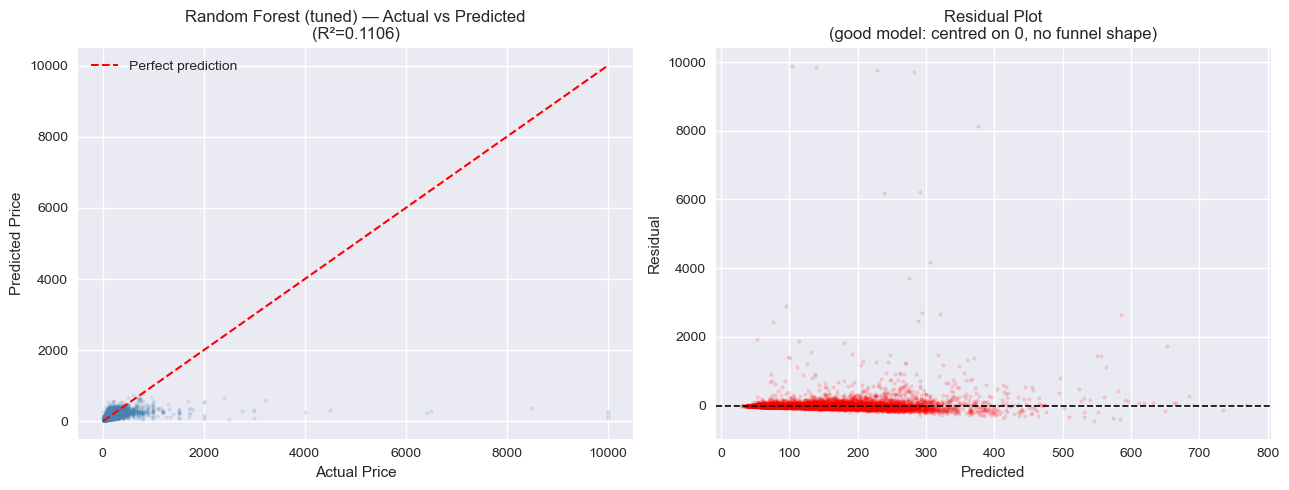

In [114]:
best_model  = rf_grid.best_estimator_
best_name   =  'Random Forest (tuned)'
y_pred_best = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_best, alpha=0.15, s=6, color='steelblue')
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title(f'{best_name} — Actual vs Predicted\n(R²={r2_score(y_test, y_pred_best):.4f})')
axes[0].legend()

# Residual plot
residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.15, s=6, color='red')
axes[1].axhline(0, color='black', lw=1.2, linestyle='--')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot\n(good model: centred on 0, no funnel shape)')

plt.tight_layout()
plt.show()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


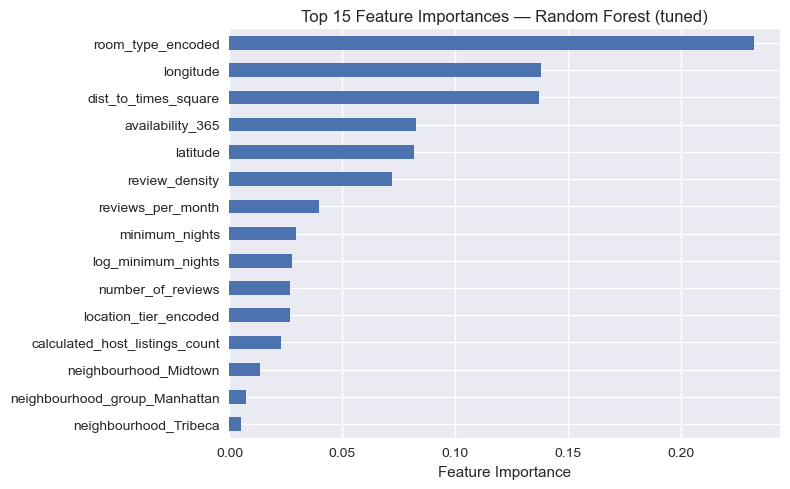

Top 5 most important features:
room_type_encoded       0.2323
longitude               0.1382
dist_to_times_square    0.1371
availability_365        0.0824
latitude                0.0819


In [74]:
top_features = importances.sort_values(ascending=False).head(15)

top_features.sort_values().plot.barh(figsize=(8,5))
plt.xlabel('Feature Importance')
plt.title(f'Top 15 Feature Importances — {best_name}')
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(importances.sort_values(ascending=False).head(5).round(4).to_string())

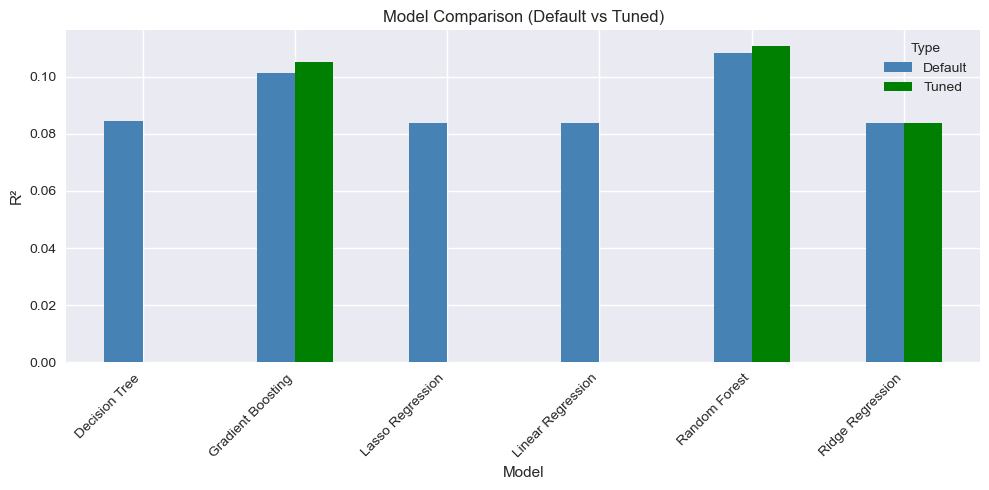

In [117]:
# plotting R² for all models (default and tuned models shown)
pivot_df = plot_df.pivot(index='Model', columns='Type', values='R2')
pivot_df.plot(kind='bar', figsize=(10,5), color=['steelblue', 'green'])
plt.ylabel('R²')
plt.title('Model Comparison (Default vs Tuned)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The results list shows that the tuned Random Forest model is the best model. It achieved the highest test performance R² of 0.1106 and RMSE of 274.70, which outperforms all other models. It also performed well with the cross-validation using capped training data, with an R² mean of 0.4461 ± 0.0212. This indicates a somewhat stable performance across all of the folds. Compared with the default model No Scaling Random Forest (R² = 0.1081), the tuned Random Forest improved R² by 0.0025.

## 6. Save Best Model


In [112]:
# Save the best model

import pickle, os
os.makedirs('../models', exist_ok=True)

with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(f'Saved:  ../models/best_model.pkl')
print(f"Model : {type(best_model).__name__}")
print(f"Params: {rf_grid.best_params_}")
print(f"Test R2: {r2_score(y_test, y_pred_best):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best)):,.0f}")

Saved:  ../models/best_model.pkl
Model : RandomForestRegressor
Params: {'max_depth': 15, 'max_features': 0.5, 'n_estimators': 200}
Test R2: 0.1106
Test RMSE: 275


In [118]:
# test the saved model on first 5 samples
import pickle

with open('../models/best_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

print("Loaded model type:", type(loaded_model).__name__)
print("Predictions for first 5 test rows:")
print(loaded_model.predict(X_test.head(5)))

Loaded model type: RandomForestRegressor
Predictions for first 5 test rows:
[ 91.04249485  82.26950645 253.71130245  58.07778227 122.37087472]


## Key Findings Summary

1. **Random Forest (Tuned)** was the best model, with the highest **test R² of 0.1106** and the lowest **test RMSE of 274.70**, slightly improving on the default model, **No Scaling Random Forest** (**R² = 0.1081**) by **0.0025 R²**.

2. Among the tuned models, **Random Forest (Tuned)** also had the strongest cross-validation performance using the capped training data with a **CV mean R² of 0.4461 ± 0.0212**, followed closely by **Gradient Boosting (Tuned)** at **0.4326 ± 0.0138**, while **Ridge (Tuned)** was last at **0.3609 ± 0.0113**.

3. Linear models performed similarly on this data: **No Scaling Linear Regression test R² = 0.0836**, **Scaling Linear Regression test R² = 0.0836**, **Scaling Ridge Regression test R² = 0.0837**, and **Scaling Lasso Regression test R² = 0.0836**, indicating that regularization and scaling had little improvement over the baseline linear regression model.

4. Tree-based models wwere able to capture more complex patterns but also showed more overfitting. **Random Forest (Tuned)** had a **train R² of 0.3477** versus **test R² of 0.1106**, while **Gradient Boosting (Tuned)** had a smaller gap with **train R² = 0.2018** and **test R² = 0.1052**. Gradient Boosting was the more balanced model over Random Forest.

5. Hyperparameter tuning produced only small improvements: **Random Forest improved by 0.0025 R²**, **Gradient Boosting improved by 0.0042 R²**, and **Ridge showed no improvement (0.0000)**. This indicates that model performance is constrained by the features more than the model configuration itself. 